### STEP A. 데이터 준비

In [ ]:
import pandas as pd
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../week1/data/cookie_cats.csv')

# 타겟 변수: D7 잔존 여부 (1=잔존, 0=이탈)
df['retained_d7'] = df['retention_7'].apply(lambda x:1 if x==True else 0)

# 독립 변수: version(A/B그룹), sum_gamerounds(플레이 라운드 수), D1 잔존 여부
df['retained_d1'] = df['retention_1'].apply(lambda x:1 if x==True else 0)
df['version_encoded'] = LabelEncoder().fit_transform(df['version'])
# gate_30 = 0, gate_40 = 1 로 인코딩됨

print(df[['version_encoded', 'sum_gamerounds', 'retained_d1', 'retained_d7']].head())


   version_encoded  sum_gamerounds  retained_d1  retained_d7
0                0               3            0            0
1                0              38            1            0
2                1             165            1            0
3                1               1            0            0
4                1             179            1            1


### STEP B. 학습/테스트 데이터 분리

In [7]:
# 독립변수(X)와 타겟변수(y) 설정
X = df[['version_encoded', 'sum_gamerounds', 'retained_d1']]
y = df['retained_d7']

# 8:2 비율로 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"학습 데이터: {len(X_train):,}행")
print(f"테스트 데이터: {len(X_test):,}행")

학습 데이터: 72,151행
테스트 데이터: 18,038행


### STEP C. 모델 학습

In [8]:
model = LogisticRegression(random_state=42)
model.fit(X_train, y_train)

# 각 변수의 계수 확인
coef_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': model.coef_[0]
}).sort_values('coefficient', ascending=False)

print("[ 변수별 계수 ]")
print(coef_df)

[ 변수별 계수 ]
           feature  coefficient
2      retained_d1     0.703837
1   sum_gamerounds     0.018301
0  version_encoded    -0.063862


### STEP D. 모델 평가

[ 분류 리포트 ]
              precision    recall  f1-score   support

           0       0.88      0.97      0.92     14661
           1       0.78      0.42      0.55      3377

    accuracy                           0.87     18038
   macro avg       0.83      0.70      0.74     18038
weighted avg       0.86      0.87      0.85     18038



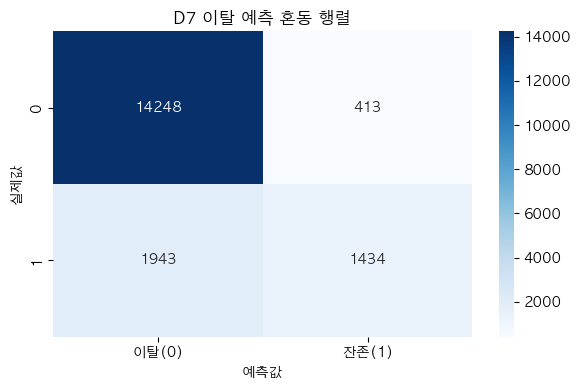

In [14]:
y_pred = model.predict(X_test)
print("[ 분류 리포트 ]")
print(classification_report(y_test, y_pred))

cm = confusion_matrix(y_test, y_pred)

plt.rc('font', family='AppleGothic')  # Mac용 AppleGothic 설정
plt.rcParams['axes.unicode_minus'] = False  # 마이너스 기호 깨짐 방지
plt.figure(figsize=(6, 4))

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['이탈(0)', '잔존(1)'])
plt.title('D7 이탈 예측 혼동 행렬')
plt.ylabel('실제값')
plt.xlabel('예측값')
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

## 분석 결론

### 변수 중요도
- retained_d1(D1 잔존 여부)의 계수가 가장 큼 ( 0.703837 )

  → D1에 잔존한 유저가 D7에도 잔존할 확률이 압도적으로 높음
- sum_gamerounds(플레이 라운드 수)도 양의 계수

  → 초반에 많이 플레이한 유저일수록 D7 잔존 가능성 높음
- version(게이트 레벨)의 계수는 상대적으로 작음

  → 사용자가 속한 게이트 레벨보다 초반 플레이 습관이 잔존률에 더 큰 영향

### 비즈니스 액션 아이템
- D1 잔존률을 높이는 것이 D7 잔존률 향상의 핵심 요소

- 초반 1~5라운드 구간 경험 개선이 가장 우선순위 높은 과제